In [40]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
def CalcTrueRange(H, L, Cp):
    a =  H -L
    b = abs(H- Cp)
    c = abs(L -Cp)
    TR = max(a , b ,c )
    return TR

In [42]:
def CalcAverageTrueRange(data, NOP):
    AtrList = []
    
    for i in range(NOP, len(data)):
        tr = CalcTrueRange(data['High'].iloc[i], data['Low'].iloc[i], data['Close'].iloc[i-1])
        atr = tr if i == NOP else ( AtrList[-1] * (NOP - 1) + tr) / NOP
        AtrList.append(atr)
    
    return pd.Series( AtrList , index=data.index[NOP:])

In [49]:
NOP = 14 
data = yf.download('AAPL', start='2021-05-23', end='2023-05-23')


[*********************100%***********************]  1 of 1 completed


In [50]:
atr = CalcAverageTrueRange(data, NOP)


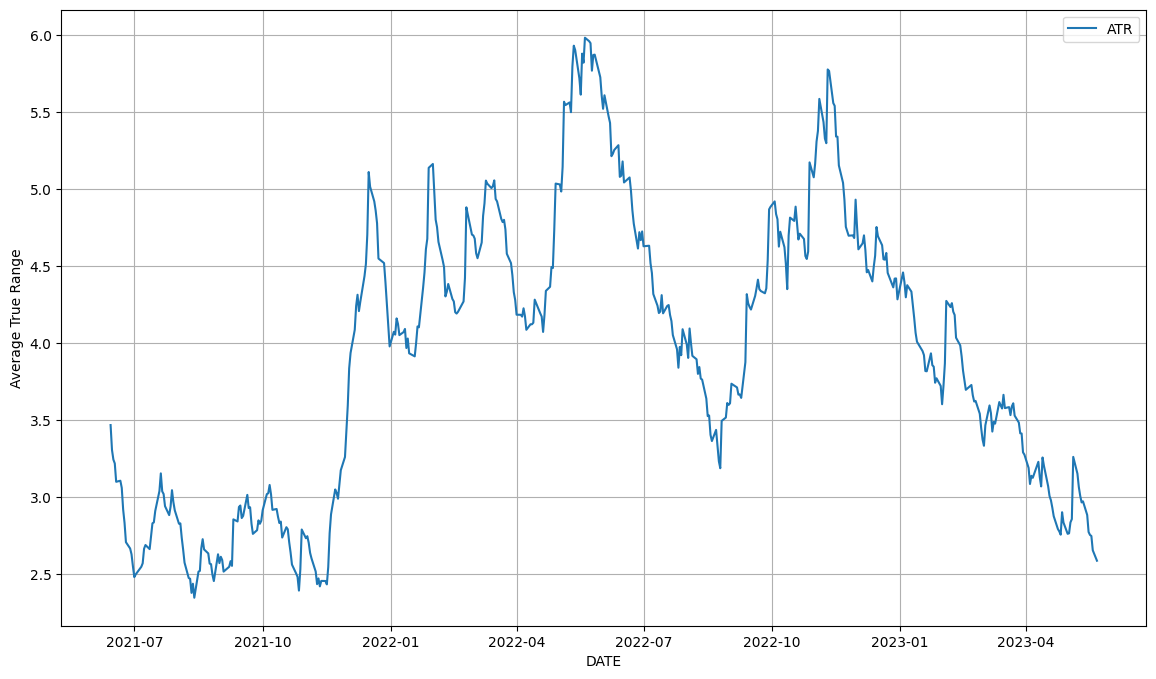

In [51]:
plt.figure(figsize=(14, 8))
plt.xlabel('DATE')
plt.ylabel('Average True Range')
plt.grid()
plt.plot( atr , label = 'ATR')
plt.legend()
